# **Convolutional Neural Network vs Vision Transformer**

## **1. Introduction to the Problem**

Bài toán image classification (phân loại ảnh) là một trong những nhiệm vụ cốt lõi của thị giác máy tính, với mục tiêu gán một nhãn duy nhất cho toàn bộ bức ảnh dựa trên nội dung mà nó chứa (ví dụ: mèo, chó, xe). Để giải quyết bài toán này, các mô hình học sâu thường được sử dụng nhằm tự động học và trích xuất các đặc trưng quan trọng từ dữ liệu ảnh, từ đó đưa ra dự đoán chính xác cho các mẫu chưa từng thấy.

Trong báo cáo này, mục tiêu là so sánh hai hướng tiếp cận tiêu biểu cho bài toán image classification: **Convolutional Neural Networks (CNN)** — vốn khai thác tốt cấu trúc không gian của ảnh thông qua các phép tích chập, và **Transformer** — một kiến trúc mới hơn dựa trên cơ chế attention, có khả năng mô hình hóa quan hệ toàn cục trong dữ liệu.

Cụ thể, báo cáo này sử dụng **ResNet-50** như một đại diện cho kiến trúc CNN và **Swin Transformer** như một đại diện cho kiến trúc Transformer. Qua đó, báo cáo nhằm làm rõ sự khác biệt trong cách biểu diễn đặc trưng cũng như hiệu quả thực nghiệm của hai mô hình trên cùng một tập dữ liệu.

## **2. Dataset - Caltech-101**

Để thực hiện việc so sánh giữa hai kiến trúc mô hình trong bài toán image classification, báo cáo này sử dụng tập dữ liệu **Caltech101**. Đây là một dataset phổ biến trong lĩnh vực thị giác máy tính, được xây dựng bởi California Institute of Technology (Caltech) nhằm phục vụ cho các nghiên cứu về nhận dạng đối tượng.

### **2.1. Overview**

[Caltech-101](https://www.tensorflow.org/datasets/catalog/caltech101) bao gồm các hình ảnh của các đối tượng thuộc 101 lớp khác nhau, cùng với một lớp bổ sung là background clutter. Mỗi ảnh được gán một nhãn duy nhất tương ứng với đối tượng chính trong ảnh.

Mỗi lớp chứa khoảng 40 đến 800 ảnh, với tổng số khoảng 9.000 ảnh. Các ảnh có kích thước không đồng nhất, với cạnh ảnh điển hình nằm trong khoảng 200–300 pixel.

Phiên bản dataset này chỉ cung cấp nhãn ở mức toàn ảnh (image-level labels). Trong khi đó, phiên bản gốc của dataset còn bao gồm thêm bounding boxes cho các đối tượng.

### **2.2. Data Distribution**

Mục này nhằm phân tích phân phối dữ liệu giữa các lớp trong tập Caltech-101, thông qua việc xem xét số lượng mẫu tương ứng với từng lớp. Việc đánh giá phân phối này giúp xác định liệu dataset có tồn tại hiện tượng mất cân bằng dữ liệu (class imbalance) hay không, từ đó làm cơ sở cho việc lựa chọn phương pháp huấn luyện và đánh giá mô hình phù hợp.

#### **Histogram**

Trước khi đưa ra các nhận xét chi tiết, cần trực quan hóa phân phối số lượng ảnh theo từng lớp thông qua biểu đồ **histogram**. Biểu đồ này cho phép quan sát tổng thể cách các lớp được phân bổ theo số lượng mẫu, từ đó cung cấp cái nhìn trực quan về mức độ đồng đều hay chênh lệch trong dataset.

100%|██████████| 137M/137M [00:10<00:00, 13.4MB/s]


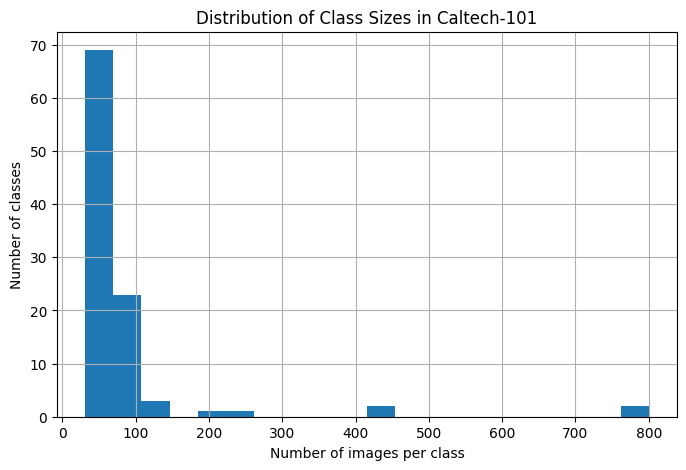

In [1]:
import torchvision
import matplotlib.pyplot as plt
from collections import Counter

# Load dataset
dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=True
)

# Lấy label của từng ảnh
labels = dataset.y  # list các class index

# Đếm số lượng ảnh mỗi class
class_counts = Counter(labels)

# Lấy số lượng ảnh của từng class
counts = list(class_counts.values())

# Vẽ histogram
plt.figure(figsize=(8, 5))
plt.hist(counts, bins=20)
plt.xlabel("Number of images per class")
plt.ylabel("Number of classes")
plt.title("Distribution of Class Sizes in Caltech-101")
plt.grid()

plt.show()

Dựa trên biểu đồ histogram, có thể nhận thấy rằng phân phối số lượng ảnh giữa các lớp trong tập Caltech-101 là không đồng đều. Cụ thể, phần lớn các lớp tập trung trong khoảng từ 40 đến 100 ảnh, trong khi chỉ có một số ít lớp sở hữu số lượng mẫu lớn hơn đáng kể (trên 200 ảnh, thậm chí gần 800 ảnh).

Phân phối này cho thấy dataset có đặc trưng lệch phải (right-skewed), với đuôi dài về phía các lớp có nhiều dữ liệu. Điều này phản ánh sự tồn tại của hiện tượng mất cân bằng dữ liệu giữa các lớp (class imbalance).

Sự mất cân bằng này có thể ảnh hưởng đến quá trình huấn luyện mô hình, khi các lớp có nhiều mẫu dễ chi phối quá trình học, trong khi các lớp có ít mẫu có thể không được học đầy đủ. Do đó, đây là một yếu tố cần được xem xét trong quá trình thiết kế thí nghiệm và đánh giá mô hình.

#### **Top-10 classes**

Để làm rõ hơn đặc điểm phân phối dữ liệu, biểu đồ top-10 classes được sử dụng nhằm thể hiện các lớp có số lượng mẫu lớn nhất trong tập dữ liệu. So với histogram, biểu đồ này cho phép quan sát trực tiếp mức độ chênh lệch về số lượng mẫu giữa các lớp có tần suất cao, qua đó cung cấp cái nhìn cụ thể hơn về sự phân bố dữ liệu. Phân tích này góp phần hỗ trợ việc nhận diện mức độ mất cân bằng giữa các lớp trong dataset.

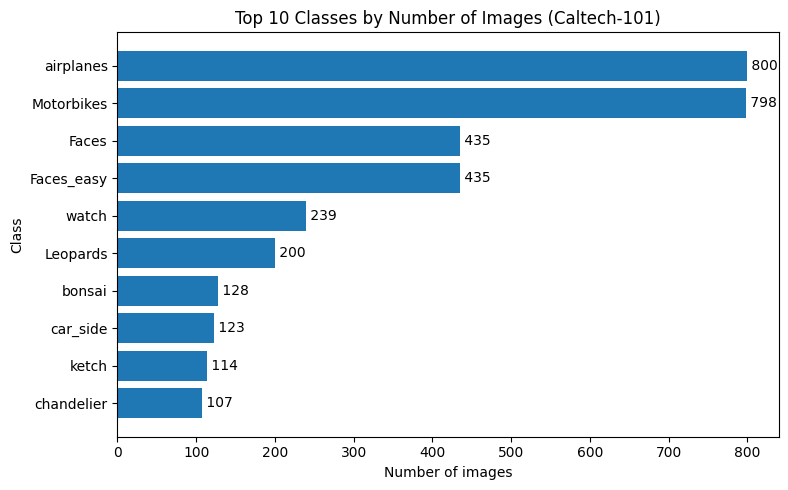

In [2]:
# import torchvision
# import matplotlib.pyplot as plt
# from collections import Counter

# Load dataset
dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=False ## down loaded before
)

# Lấy label
labels = [label for _, label in dataset]

# Đếm số lượng ảnh mỗi class
class_counts = Counter(labels)

# Lấy top 10 class
top_k = 10
top_classes = class_counts.most_common(top_k)

# Lấy tên class
class_names = dataset.categories
names = [class_names[c[0]] for c in top_classes]
counts = [c[1] for c in top_classes]

# Đảo thứ tự để class lớn nhất nằm trên cùng
names = names[::-1]
counts = counts[::-1]

# Vẽ horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(names, counts)

plt.xlabel("Number of images")
plt.ylabel("Class")
plt.title("Top 10 Classes by Number of Images (Caltech-101)")

# Hiển thị số lên thanh
for i, v in enumerate(counts):
    plt.text(v, i, f" {v}", va='center')

plt.tight_layout()
plt.show()

Biểu đồ cho thấy sự chênh lệch đáng kể về số lượng mẫu giữa các lớp trong tập Caltech-101. Cụ thể, hai lớp 8*airplanes** và **Motorbikes** có số lượng ảnh vượt trội (xấp xỉ 800 ảnh), cao hơn đáng kể so với các lớp còn lại. Nhóm tiếp theo như **Faces** và **Faces_easy** cũng có số lượng tương đối lớn (~435 ảnh), tuy nhiên vẫn thấp hơn gần một nửa so với hai lớp dẫn đầu.

Các lớp còn lại trong top 10 có số lượng ảnh giảm dần rõ rệt, dao động trong khoảng từ khoảng 100 đến 250 ảnh. Sự suy giảm này cho thấy phân phối dữ liệu không đồng đều ngay cả trong nhóm các lớp có nhiều mẫu nhất.

Từ đó có thể nhận thấy rằng dataset tồn tại hiện tượng tập trung dữ liệu vào một số ít lớp, trong khi phần lớn các lớp còn lại có số lượng mẫu thấp hơn đáng kể. Điều này củng cố nhận định từ phân tích trước đó về mất cân bằng dữ liệu, và cho thấy mức độ chênh lệch không chỉ tồn tại trên toàn bộ dataset mà còn rõ ràng ngay trong nhóm các lớp có tần suất cao.

### **2.3. Data Characteristics**

#### **Image Size Distribution**

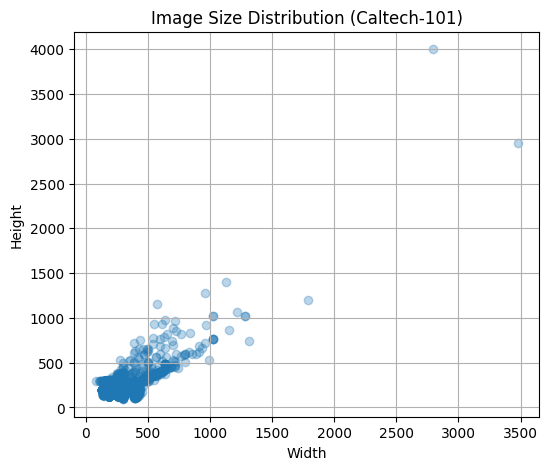

In [3]:
from PIL import Image
import os
import matplotlib.pyplot as plt

root = "./data/caltech101/101_ObjectCategories"

widths = []
heights = []

for class_name in os.listdir(root):
    class_path = os.path.join(root, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            continue

# Plot
plt.figure(figsize=(6,5))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Size Distribution (Caltech-101)")
plt.grid()
plt.show()

Dựa trên biểu đồ phân phối kích thước ảnh, có thể nhận thấy rằng các ảnh trong tập Caltech-101 không có kích thước đồng nhất. Phần lớn các mẫu tập trung trong khoảng từ 200 đến 600 pixels cho cả chiều rộng và chiều cao, cho thấy đa số ảnh có độ phân giải ở mức trung bình.

Tuy nhiên, vẫn tồn tại một số lượng nhỏ các ảnh có kích thước lớn hơn đáng kể, nằm tách biệt khỏi vùng phân bố chính. Những trường hợp này có thể được xem là các điểm ngoại lệ về kích thước.

Ngoài ra, sự phân tán của các điểm dữ liệu cho thấy không tồn tại một tỉ lệ khung hình cố định giữa các ảnh. Điều này phản ánh sự đa dạng về hình dạng ảnh trong dataset và cho thấy cần có bước chuẩn hóa phù hợp trong quá trình tiền xử lý dữ liệu.

#### **Aspect Ratio**

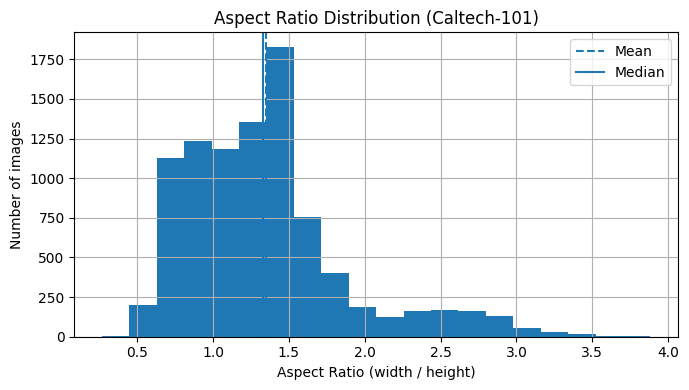

In [4]:
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

root = "./data/caltech101/101_ObjectCategories"

aspect_ratios = []

for class_name in os.listdir(root):
    class_path = os.path.join(root, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            w, h = img.size
            aspect_ratios.append(w / h)
        except:
            continue

# Convert sang numpy
aspect_ratios = np.array(aspect_ratios)

# Vẽ histogram
plt.figure(figsize=(7, 4))
plt.hist(aspect_ratios, bins=20)

plt.xlabel("Aspect Ratio (width / height)")
plt.ylabel("Number of images")
plt.title("Aspect Ratio Distribution (Caltech-101)")

# Mean + median (optional nhưng rất nên có)
plt.axvline(np.mean(aspect_ratios), linestyle='--', label='Mean')
plt.axvline(np.median(aspect_ratios), linestyle='-', label='Median')

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Phân phối aspect ratio của tập Caltech-101 cho thấy phần lớn các ảnh có tỉ lệ khung hình tập trung quanh khoảng 1.0–1.5, với giá trị trung vị xấp xỉ ~1.3. Điều này cho thấy đa số ảnh có xu hướng gần vuông hoặc hơi nghiêng theo chiều ngang (width > height).

Tuy nhiên, phân phối có đuôi phải kéo dài (right-skewed), với một số lượng không nhỏ các ảnh có aspect ratio lớn hơn 2.0 và thậm chí vượt quá 3.0. Điều này phản ánh sự tồn tại của các ảnh có dạng rất dẹt theo chiều ngang, tạo nên sự không đồng nhất về hình dạng trong dataset. Ngược lại, các ảnh có aspect ratio nhỏ hơn 1.0 (dạng dọc) xuất hiện ít hơn và phân bố hẹp hơn.

Sự bất cân xứng trong phân phối (mean > median) cho thấy ảnh hưởng của các outliers phía bên phải. Từ góc độ tiền xử lý, đặc điểm này hàm ý rằng việc resize ảnh về kích thước cố định (ví dụ 224×224) có thể gây biến dạng đáng kể đối với một số mẫu. Do đó, các chiến lược như padding giữ nguyên tỉ lệ (aspect ratio preserving resize) hoặc center crop sau resize nên được cân nhắc nhằm giảm thiểu mất mát thông tin hình học.

#### **Visual Characteristics**

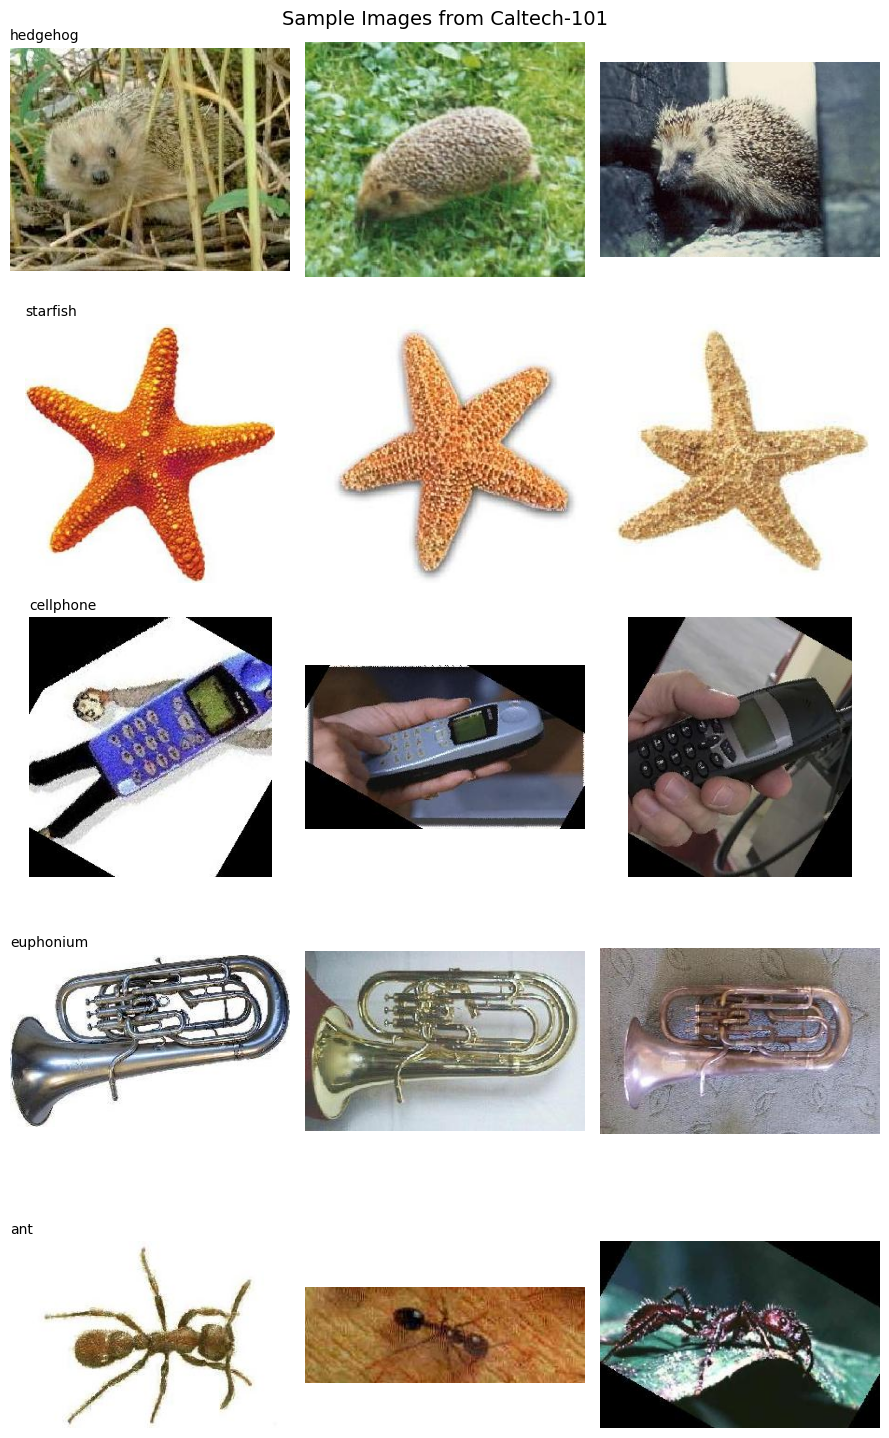

In [5]:
import torchvision
import matplotlib.pyplot as plt
import random

# Load dataset
dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=False
)

# Lấy danh sách class
classes = dataset.categories

# Chọn ngẫu nhiên K class
K = 5
samples_per_class = 3
selected_classes = random.sample(range(len(classes)), K)

# Tạo mapping class -> list index ảnh
class_to_indices = {i: [] for i in selected_classes}

for idx, label in enumerate(dataset.y):
    if label in class_to_indices:
        class_to_indices[label].append(idx)

# Vẽ grid
fig, axes = plt.subplots(K, samples_per_class, figsize=(samples_per_class * 3, K * 3))

for row, class_idx in enumerate(selected_classes):
    indices = class_to_indices[class_idx]
    sampled_indices = random.sample(indices, samples_per_class)

    for col, img_idx in enumerate(sampled_indices):
        img, _ = dataset[img_idx]
        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        # Ghi tên class ở cột đầu
        if col == 0:
            axes[row, col].set_title(classes[class_idx], loc='left', fontsize=10)

plt.suptitle("Sample Images from Caltech-101", fontsize=14)
plt.tight_layout()
plt.show()

## **3. Dataset Preparation**

In [ ]:
# Core
import torch
import torch.nn as nn
import torch.optim as optim
import time

# Model library
import timm

# Dataset & transforms
import torchvision
import torchvision.transforms as transforms

# Data utilities
from torch.utils.data import DataLoader, random_split

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)

In [ ]:
# normalization
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

# load dataset
dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=True,
    transform=transform
)

# split train / test
train_size = int(0.8 * len(dataset)) # train - test = 80 : 20
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

## **4. Model Fine-tuning on the Dataset**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# load models
resnet = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=101
).to(device)

swin = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=101
).to(device)

In [ ]:
def train(model, loader, optimizer, epochs=5):

    criterion = nn.CrossEntropyLoss()

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        all_preds = []
        all_labels = []

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        epoch_loss = total_loss / len(loader)

        acc = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
        f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Loss: {epoch_loss:.4f}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-score: {f1:.4f}")
        print()

    total_training_time = time.time() - start_time

    print("Total Training Time:", total_training_time)

    return total_training_time

In [ ]:
def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    start = time.time()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1).cpu()

            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())

    total_time = time.time() - start

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")

    return acc, f1, precision, recall, total_time

In [ ]:
def evaluate_ensemble(model1, model2, loader):

    model1.eval()
    model2.eval()

    all_preds = []
    all_labels = []

    start = time.time()

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            logits1 = model1(images)
            logits2 = model2(images)

            logits = (logits1 + logits2) / 2   # ensemble

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    total_time = time.time() - start

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, f1, precision, recall, total_time

In [ ]:
import torch.optim as optim
from enum import Enum

class TrainStrategy(Enum):
    FREEZE_BACKBONE = 1
    FULL_FINE_TUNE = 2
    LAYER_WISE = 3

def build_optimizer(model, strategy):

    if strategy == TrainStrategy.FREEZE_BACKBONE:

        for param in model.parameters():
            param.requires_grad = False

        # ResNet
        if hasattr(model, "fc"):
            for param in model.fc.parameters():
                param.requires_grad = True

        # Swin
        if hasattr(model, "head"):
            for param in model.head.parameters():
                param.requires_grad = True

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-3
        )

    elif strategy == TrainStrategy.FULL_FINE_TUNE:

        for param in model.parameters():
            param.requires_grad = True

        optimizer = optim.Adam(
            model.parameters(),
            lr=1e-4
        )

    elif strategy == TrainStrategy.LAYER_WISE:

        if hasattr(model, "layer1"):  # ResNet

            optimizer = optim.Adam([
                {"params": model.layer1.parameters(), "lr": 1e-5},
                {"params": model.layer2.parameters(), "lr": 3e-5},
                {"params": model.layer3.parameters(), "lr": 5e-5},
                {"params": model.layer4.parameters(), "lr": 7e-5},
                {"params": model.fc.parameters(), "lr": 1e-4},
            ])

        elif hasattr(model, "layers"):  # Swin

            optimizer = optim.Adam([
                {"params": model.layers[0].parameters(), "lr": 1e-5},
                {"params": model.layers[1].parameters(), "lr": 3e-5},
                {"params": model.layers[2].parameters(), "lr": 5e-5},
                {"params": model.layers[3].parameters(), "lr": 7e-5},
                {"params": model.head.parameters(), "lr": 1e-4},
            ])

    return optimizer

In [ ]:
# training
# strategy = TrainStrategy.FREEZE_BACKBONE
strategy = TrainStrategy.FULL_FINE_TUNE
# strategy = TrainStrategy.LAYER_WISE

resnet_optimizer = build_optimizer(resnet, strategy)
swin_optimizer = build_optimizer(swin, strategy)

print("\nTraining ResNet50")
train(resnet, train_loader, resnet_optimizer, epochs=5)

print("\nTraining Swin Transformer")
train(swin, train_loader, swin_optimizer, epochs=5)

In [ ]:
# test
resnet_acc, resnet_f1, resnet_precision, resnet_recall, resnet_time = evaluate(resnet, test_loader)
swin_acc, swin_f1, swin_precision, swin_recall, swin_time = evaluate(swin, test_loader)

# ensemble_acc, ensemble_f1, ensemble_precision, ensemble_recall, ensemble_time = evaluate_ensemble(
#     resnet, swin, test_loader
# )

num_images = len(test_dataset)

print("===== ResNet50 =====")
print(f"Accuracy: {resnet_acc:.4f}")
print(f"Precision: {resnet_precision:.4f}")
print(f"Recall: {resnet_recall:.4f}")
print(f"F1 Score: {resnet_f1:.4f}")
print(f"Total inference time: {resnet_time:.2f} s")
print(f"Latency per image: {resnet_time/num_images:.6f} s")
print(f"Throughput: {num_images/resnet_time:.2f} images/s")

print()

print("===== Swin Transformer =====")
print(f"Accuracy: {swin_acc:.4f}")
print(f"Precision: {swin_precision:.4f}")
print(f"Recall: {swin_recall:.4f}")
print(f"F1 Score: {swin_f1:.4f}")
print(f"Total inference time: {swin_time:.2f} s")
print(f"Latency per image: {swin_time/num_images:.6f} s")
print(f"Throughput: {num_images/swin_time:.2f} images/s")

print()
print("===== Ensemble (ResNet + Swin) =====")
print(f"Accuracy: {ensemble_acc:.4f}")
print(f"Precision: {ensemble_precision:.4f}")
print(f"Recall: {ensemble_recall:.4f}")
print(f"F1 Score: {ensemble_f1:.4f}")
print(f"Total inference time: {ensemble_time:.2f} s")
print(f"Latency per image: {ensemble_time/num_images:.6f} s")
print(f"Throughput: {num_images/ensemble_time:.2f} images/s")

## **5. Experimental Results and Evaluation**

### **5.1. Performance Comparison**

Trong phần này, chúng tôi tiến hành so sánh hiệu năng của ba kiến trúc mô hình bao gồm CNN-based (ResNet50), Transformer-based (Swin) và mô hình lai (ResNet50 + Swin) dưới ba chiến lược huấn luyện khác nhau: đóng băng backbone (Freeze), fine-tuning toàn bộ (Full Fine-tuning) và fine-tuning theo từng lớp (Layer-wise Fine-tuning). Việc đánh giá được thực hiện thông qua các chỉ số phổ biến trong bài toán phân loại, bao gồm Accuracy, Precision, Recall và F1-score. Mục tiêu là làm rõ sự khác biệt giữa hai hướng tiếp cận CNN và Transformer, đồng thời phân tích liệu việc kết hợp hai kiến trúc có mang lại cải thiện đáng kể về hiệu năng hay không.

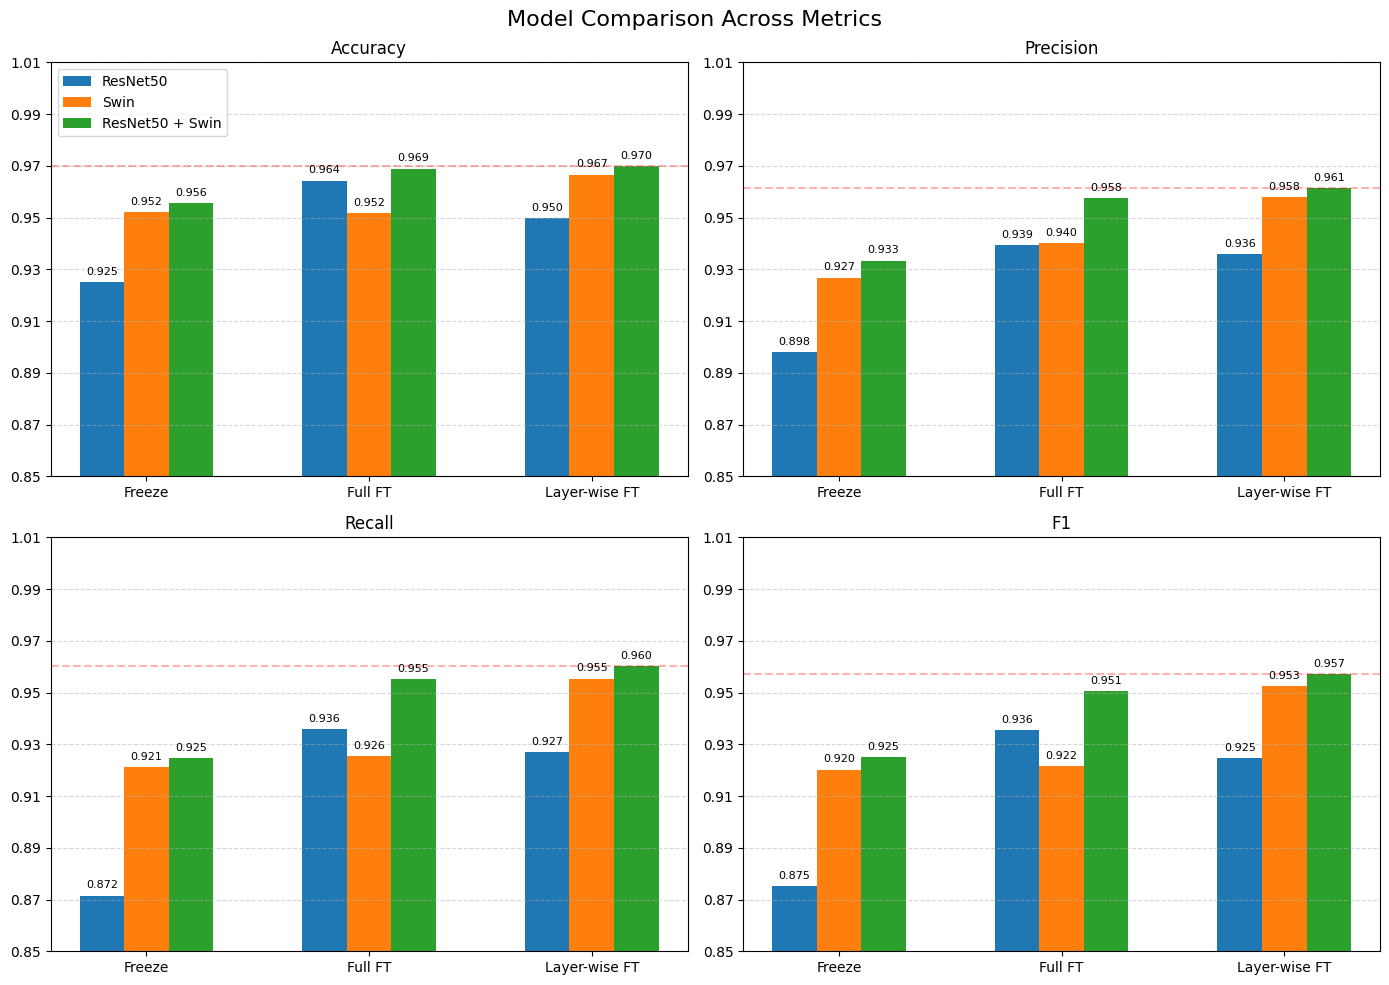

In [7]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
strategies = ['Freeze', 'Full FT', 'Layer-wise FT']
models = ['ResNet50', 'Swin', 'ResNet50 + Swin']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green

# Data
data = {
    'Freeze': [
        [0.9251, 0.8979, 0.8715, 0.8751],
        [0.9522, 0.9268, 0.9213, 0.9202],
        [0.9556, 0.9334, 0.9246, 0.9250]
    ],
    'Full FT': [
        [0.9643, 0.9394, 0.9358, 0.9356],
        [0.9516, 0.9402, 0.9256, 0.9216],
        [0.9689, 0.9576, 0.9551, 0.9507]
    ],
    'Layer-wise FT': [
        [0.9499, 0.9359, 0.9270, 0.9246],
        [0.9666, 0.9579, 0.9554, 0.9525],
        [0.9700, 0.9613, 0.9603, 0.9572]
    ]
}

fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

width = 0.2
x = np.arange(len(strategies))

for m_idx, metric in enumerate(metrics):
    ax = axes[m_idx]

    all_values = []

    for i in range(3):  # models
        values = [data[s][i][m_idx] for s in strategies]
        all_values.extend(values)

        bars = ax.bar(x + i*width - width, values, width,
                      label=models[i], color=colors[i])

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.002,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    max_val = max(all_values)
    ax.axhline(max_val, linestyle='--', alpha=0.3, color='red')

    ax.set_title(metric, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies)

    ax.set_ylim(0.85, 1.0)
    ax.set_yticks(np.arange(0.85, 1.01, 0.02))

    ax.grid(axis='y', linestyle='--', alpha=0.5)

axes[0].legend(loc='upper left')
plt.suptitle('Model Comparison Across Metrics', fontsize=16)

plt.tight_layout()
plt.show()

Kết quả thực nghiệm cho thấy mô hình Transformer (Swin) nhìn chung vượt trội hơn so với mô hình CNN truyền thống (ResNet50) trên hầu hết các chỉ số, đặc biệt là Precision, Recall và F1-score, cho thấy khả năng nắm bắt thông tin ngữ cảnh toàn cục tốt hơn. Trong khi đó, ResNet50 có xu hướng đạt kết quả thấp hơn nhưng ổn định, đặc biệt khi không thực hiện fine-tuning. Đáng chú ý, mô hình lai ResNet50 + Swin consistently đạt hiệu năng cao nhất trong tất cả các thiết lập, với F1-score cao nhất ở chiến lược Layer-wise Fine-tuning, cho thấy việc kết hợp đặc trưng cục bộ của CNN và khả năng modeling toàn cục của Transformer mang lại lợi ích rõ rệt.

Ngoài ra, chiến lược huấn luyện cũng ảnh hưởng đáng kể đến hiệu năng. Cụ thể, việc chuyển từ Freeze sang Full Fine-tuning giúp cải thiện rõ rệt các chỉ số đối với tất cả các mô hình, trong khi Layer-wise Fine-tuning tiếp tục nâng cao hiệu năng và trong một số trường hợp còn vượt nhẹ Full Fine-tuning. Điều này cho thấy việc điều chỉnh có chọn lọc các tầng trong mạng có thể giúp mô hình học hiệu quả hơn mà không cần tối ưu toàn bộ tham số. Tổng thể, kết quả nhấn mạnh rằng Transformer và đặc biệt là mô hình lai là hướng tiếp cận tiềm năng để đạt hiệu năng cao, với điều kiện có đủ tài nguyên để huấn luyện.

### **5.2. Efficiency Comparison**

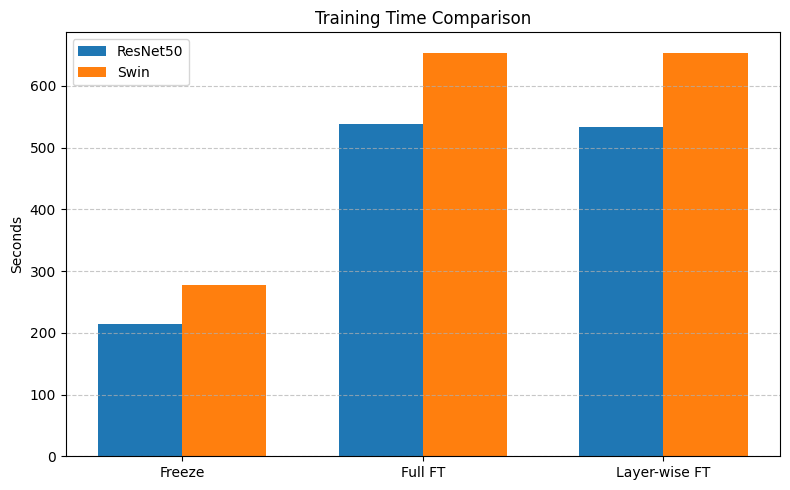

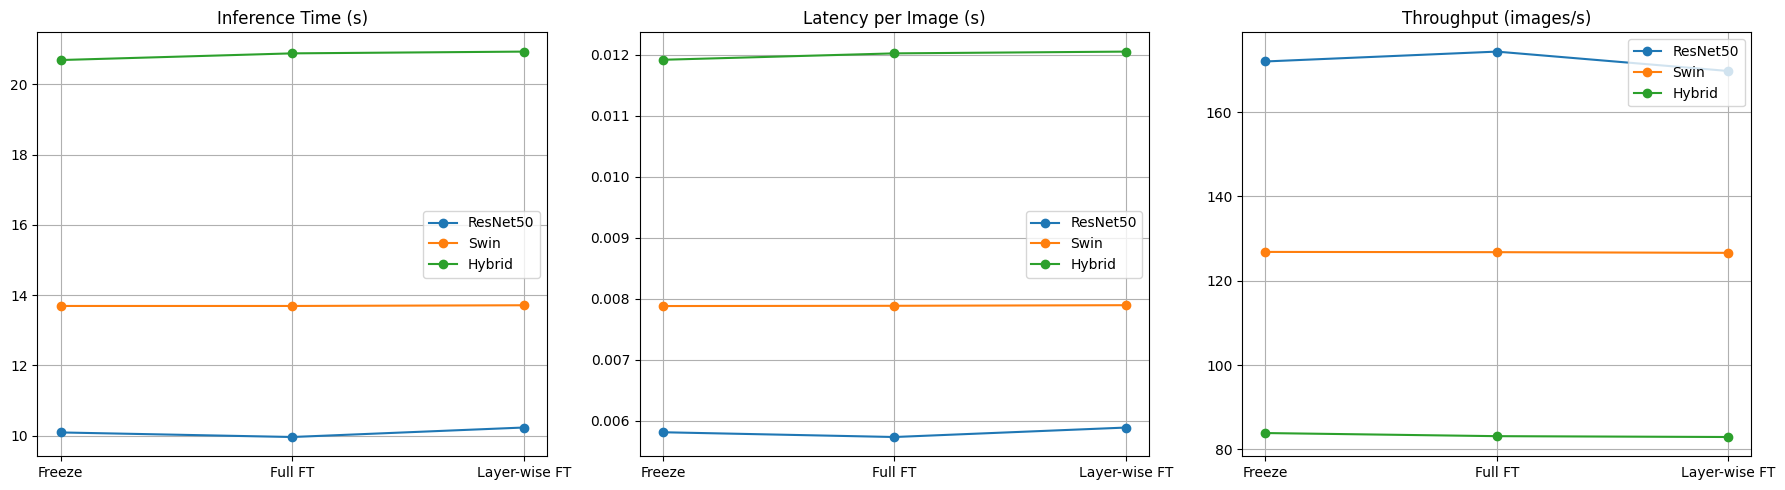

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Labels
methods = ['Freeze', 'Full FT', 'Layer-wise FT']

# ===== DATA =====
# Training Time (NO hybrid)
resnet_train = [214.27, 537.69, 533.41]
swin_train   = [278.10, 654.22, 654.06]

# Inference Time
resnet_inf = [10.09, 9.96, 10.23]
swin_inf   = [13.69, 13.69, 13.71]
hybrid_inf = [20.69, 20.88, 20.93]

# Latency
resnet_lat = [0.005814, 0.005736, 0.005891]
swin_lat   = [0.007883, 0.007887, 0.007897]
hybrid_lat = [0.011920, 0.012025, 0.012054]

# Throughput
resnet_thr = [172.01, 174.35, 169.75]
swin_thr   = [126.85, 126.79, 126.63]
hybrid_thr = [83.90, 83.16, 82.96]

x = np.arange(len(methods))
width = 0.35

# ===== PLOT 1: Training Time =====
plt.figure(figsize=(8,5))
plt.bar(x - width/2, resnet_train, width, label='ResNet50')
plt.bar(x + width/2, swin_train, width, label='Swin')

plt.xticks(x, methods)
plt.ylabel('Seconds')
plt.title('Training Time Comparison')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ===== PLOT 2: Inference Efficiency =====
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# --- Inference Time ---
axs[0].plot(methods, resnet_inf, marker='o', label='ResNet50')
axs[0].plot(methods, swin_inf, marker='o', label='Swin')
axs[0].plot(methods, hybrid_inf, marker='o', label='Hybrid')
axs[0].set_title('Inference Time (s)')
axs[0].grid(True)

# --- Latency ---
axs[1].plot(methods, resnet_lat, marker='o', label='ResNet50')
axs[1].plot(methods, swin_lat, marker='o', label='Swin')
axs[1].plot(methods, hybrid_lat, marker='o', label='Hybrid')
axs[1].set_title('Latency per Image (s)')
axs[1].grid(True)

# --- Throughput ---
axs[2].plot(methods, resnet_thr, marker='o', label='ResNet50')
axs[2].plot(methods, swin_thr, marker='o', label='Swin')
axs[2].plot(methods, hybrid_thr, marker='o', label='Hybrid')
axs[2].set_title('Throughput (images/s)')
axs[2].grid(True)

for ax in axs:
    ax.legend()

plt.tight_layout()
plt.show()

### **5.3. Accuracy vs Efficiency Trade-off**

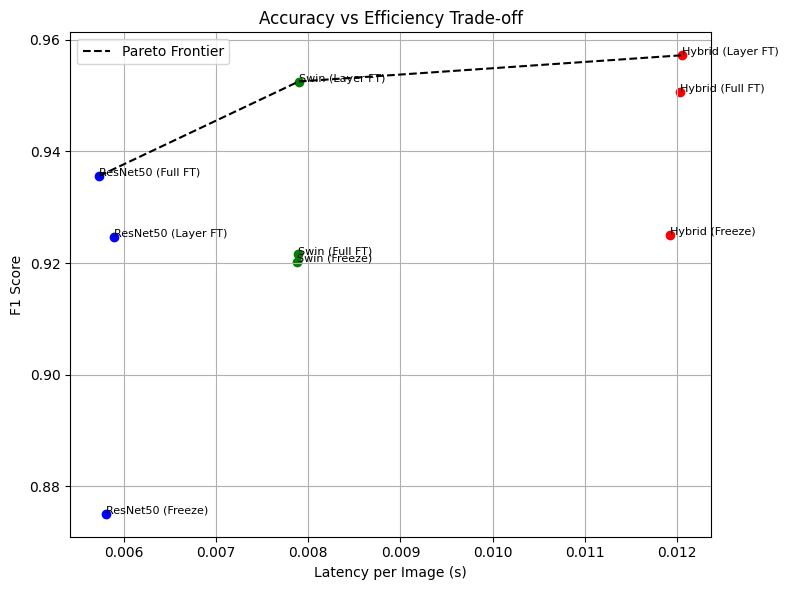

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ===== DATA =====
models = [
    'ResNet50 (Freeze)', 'Swin (Freeze)', 'Hybrid (Freeze)',
    'ResNet50 (Full FT)', 'Swin (Full FT)', 'Hybrid (Full FT)',
    'ResNet50 (Layer FT)', 'Swin (Layer FT)', 'Hybrid (Layer FT)'
]

# F1 Score
f1 = np.array([
    0.8751, 0.9202, 0.9250,
    0.9356, 0.9216, 0.9507,
    0.9246, 0.9525, 0.9572
])

# Latency
latency = np.array([
    0.005814, 0.007883, 0.011920,
    0.005736, 0.007887, 0.012025,
    0.005891, 0.007897, 0.012054
])

# ===== PLOT =====
plt.figure(figsize=(8,6))

# Scatter plot
for i, name in enumerate(models):
    if "ResNet" in name:
        color = 'blue'
    elif "Swin" in name:
        color = 'green'
    else:
        color = 'red'

    plt.scatter(latency[i], f1[i], color=color)
    plt.text(latency[i], f1[i], name, fontsize=8)

# ===== Pareto Frontier =====
# Sort by latency
sorted_idx = np.argsort(latency)
pareto_x = []
pareto_y = []

best_f1 = -1
for i in sorted_idx:
    if f1[i] > best_f1:
        pareto_x.append(latency[i])
        pareto_y.append(f1[i])
        best_f1 = f1[i]

plt.plot(pareto_x, pareto_y, linestyle='--', color='black', label='Pareto Frontier')

# Labels
plt.xlabel('Latency per Image (s)')
plt.ylabel('F1 Score')
plt.title('Accuracy vs Efficiency Trade-off')

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

### **5.5 Effect of Augmentation Strategy**

/tmp/ipykernel_31993/2654070732.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(conditions, rotation=20)
/tmp/ipykernel_31993/2654070732.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(conditions, rotation=20)


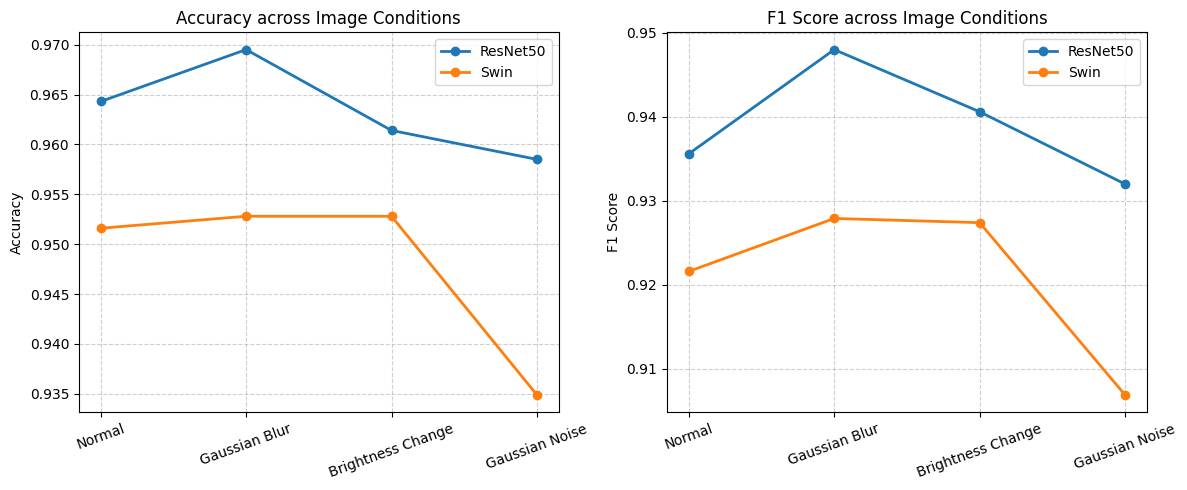

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ===== DATA =====
conditions = ['Normal', 'Gaussian Blur', 'Brightness Change', 'Gaussian Noise']

# Accuracy
resnet_acc = [0.9643, 0.9695, 0.9614, 0.9585]
swin_acc   = [0.9516, 0.9528, 0.9528, 0.9349]

# F1 Score
resnet_f1 = [0.9356, 0.9480, 0.9406, 0.9320]
swin_f1   = [0.9216, 0.9279, 0.9274, 0.9069]

# ===== PLOT =====
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# ---- Accuracy Plot ----
axs[0].plot(conditions, resnet_acc, marker='o', linewidth=2, label='ResNet50')
axs[0].plot(conditions, swin_acc, marker='o', linewidth=2, label='Swin')

axs[0].set_title('Accuracy across Image Conditions')
axs[0].set_ylabel('Accuracy')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# ---- F1 Score Plot ----
axs[1].plot(conditions, resnet_f1, marker='o', linewidth=2, label='ResNet50')
axs[1].plot(conditions, swin_f1, marker='o', linewidth=2, label='Swin')

axs[1].set_title('F1 Score across Image Conditions')
axs[1].set_ylabel('F1 Score')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# Rotate x labels for readability
for ax in axs:
    ax.set_xticklabels(conditions, rotation=20)

plt.tight_layout()
plt.show()

Qua các kết quả thực nghiệm, có thể thấy rằng mô hình ResNet50 consistently đạt hiệu năng cao hơn so với Swin Transformer trên cả hai chỉ số Accuracy và F1-score trong tất cả các điều kiện ảnh. Sự chênh lệch rõ rệt nhất xuất hiện ở điều kiện Gaussian Blur, nơi ResNet50 tận dụng tốt khả năng trích xuất đặc trưng cục bộ thông qua các convolution filters, trong khi Swin Transformer có xu hướng phụ thuộc nhiều hơn vào cấu trúc patch và attention, khiến việc nắm bắt chi tiết bị suy giảm khi ảnh bị làm mờ.

Đối với điều kiện Brightness Change, cả hai mô hình đều duy trì hiệu năng tương đối ổn định. Điều này cho thấy các mô hình học sâu hiện đại có khả năng học được các đặc trưng bất biến với thay đổi cường độ sáng, đặc biệt khi đã được pretrained trên các tập dữ liệu lớn.

Tuy nhiên, ở điều kiện Gaussian Noise, hiệu năng của cả hai mô hình đều suy giảm đáng kể, đặc biệt là Swin Transformer. Nguyên nhân chính là do noise làm phá vỡ cấu trúc thống kê của ảnh ở mức pixel, khiến các đặc trưng đầu vào trở nên kém tin cậy. Đối với CNN như ResNet50, mặc dù các convolution filters có khả năng làm trơn và khử nhiễu ở một mức độ nhất định, nhưng khi noise đủ lớn, các feature maps vẫn bị ảnh hưởng. Trong khi đó, Swin Transformer xử lý ảnh dưới dạng các patch rời rạc; khi mỗi patch đều bị nhiễu, cơ chế self-attention sẽ khó xác định được mối quan hệ thực sự giữa các vùng ảnh, dẫn đến việc lan truyền nhiễu trong toàn bộ quá trình tính toán attention.

Tóm lại, ResNet50 cho thấy độ robust tốt hơn trước các biến đổi nhiễu và mờ, trong khi Swin Transformer nhạy cảm hơn với các biến dạng làm suy giảm chất lượng tín hiệu đầu vào, đặc biệt là noise.

## **6. Conclusion**

Qua các kết quả thực nghiệm cho thấy, Swin Transformer mang lại hiệu quả phân loại vượt trội so với ResNet-50 trong cả ba kịch bản fine-tuning (free backbone, full tuning và layer-wise tuning), cho thấy khả năng học biểu diễn đặc trưng toàn cục tốt hơn. Tuy nhiên, ResNet-50 vẫn chiếm ưu thế về thời gian huấn luyện và suy luận với throughput cao hơn. Đáng chú ý, việc kết hợp (ensemble) hai mô hình giúp đạt hiệu năng tốt nhất, dù phải đánh đổi bằng độ trễ khi suy luận. Ngoài ra, Gaussian Blur được ghi nhận là kỹ thuật tiền xử lý hiệu quả, giúp cải thiện Accuracy và F1-score cho cả hai mô hình.